Loading data...
Loading datasets...
Filtering valid account snapshots...
Applying strict snapshot filter to prevent look-ahead bias...
Filtered down to 12716 clean, leak-free consumers.
Extracting features...
Extracting full habit matrix...
testset size =  1976
Training Pilot Model on 1912 features...
Model trained and ready for SHAP!


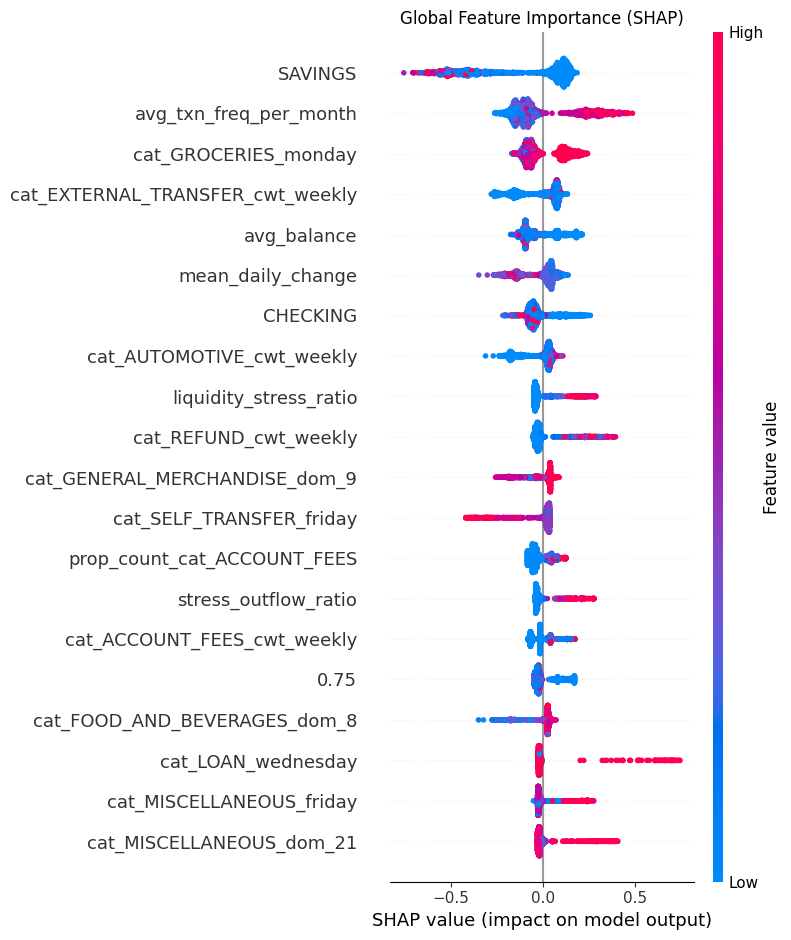

Explaining User Index: 1676 (Predicted Prob: 0.9073)


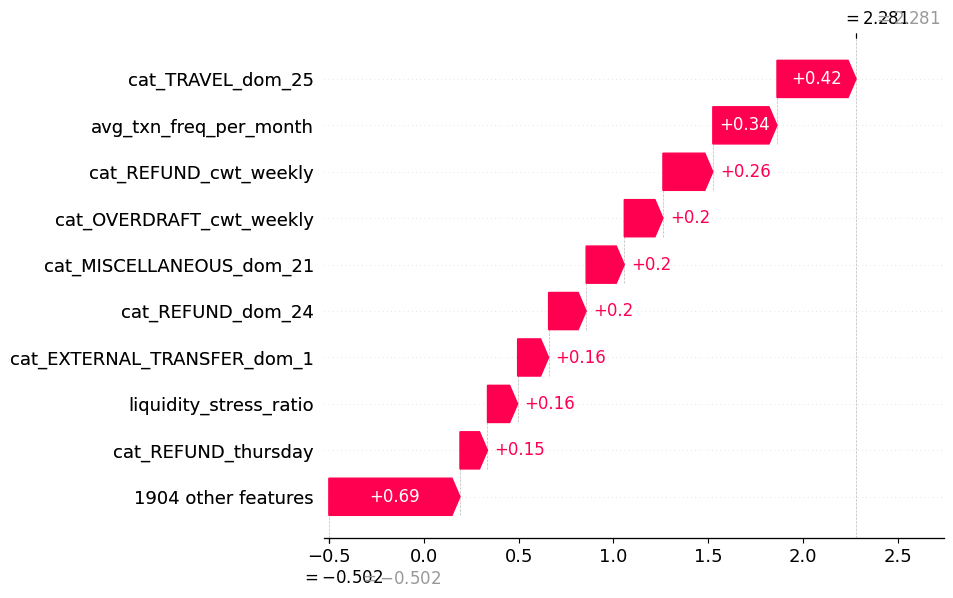

In [19]:
import os
import sys
import numpy as np
import pandas as pd
import xgboost as xgb
import shap
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_predict
from sklearn.metrics import roc_curve

# Environment Setup
sys.path.append(os.path.abspath('.'))
from data_loader import load_and_clean_data
from features import calculate_running_balance, extract_ALL_features, add_knn_error_features

# Initialize SHAP for Jupyter
shap.initjs()

# 1. DATA LOADING & FEATURE EXTRACTION
# 1. DATA LOADING, FILTERING, & FEATURE EXTRACTION
print("Loading data...")
data_path = '../data' 
consDF, acctDF, trxnDF = load_and_clean_data(data_path)

# --- THE ANTI-LEAKAGE FILTER ---
print("Applying strict snapshot filter to prevent look-ahead bias...")
acctDF['balance_date'] = pd.to_datetime(acctDF['balance_date'])
date_stats = acctDF.groupby('prism_consumer_id')['balance_date'].agg(['min', 'max'])

# Only keep consumers whose data was pulled within a tight 48-hour window
valid_ids = date_stats[(date_stats['max'] - date_stats['min']).dt.days <= 2].index

consDF = consDF[consDF['prism_consumer_id'].isin(valid_ids)]
acctDF = acctDF[acctDF['prism_consumer_id'].isin(valid_ids)]
trxnDF = trxnDF[trxnDF['prism_consumer_id'].isin(valid_ids)]
print(f"Filtered down to {len(valid_ids)} clean, leak-free consumers.")
# -------------------------------

print("Extracting features...")
history_all = calculate_running_balance(trxnDF, acctDF)
master_features_df = extract_ALL_features(history_all, acctDF)

# STRICT TARGET FILTER
# STRICT TARGET FILTER
master_features_df = master_features_df.dropna(subset=['DQ_TARGET'])

# --- THE LEAKAGE FIX ---
# Collapse multiple accounts down to exactly one row per consumer
master_features_df = master_features_df.groupby('prism_consumer_id').max().reset_index()
# -----------------------

# 2. TRAIN/TEST SPLIT (Seed 111 for presentation consistency)
train_df, test_df = train_test_split(
    master_features_df, test_size=0.2,
    stratify=master_features_df['DQ_TARGET'], random_state=42
)

# ... (The rest of your pruning and training code remains exactly the same!) ...

# 3. SURGICAL PRUNING (Zero-Variance & Redundancy)
X_train_pre = train_df.drop(columns=['DQ_TARGET', 'prism_consumer_id', 'posted_date'], errors='ignore')
X_test_pre = test_df.drop(columns=['DQ_TARGET', 'prism_consumer_id', 'posted_date'], errors='ignore')

variances = X_train_pre.var()
zero_var_cols = variances[variances == 0].index
exact_duplicates = ['std_daily_change', 'prop_count_cat_OVERDRAFT', '0.25']
monthly_cwt_cols = [col for col in X_train_pre.columns if '_cwt_monthly' in col]

to_drop = list(zero_var_cols) + exact_duplicates + monthly_cwt_cols
X_train_full = X_train_pre.drop(columns=[c for c in to_drop if c in X_train_pre.columns])
X_test_full = X_test_pre.drop(columns=[c for c in to_drop if c in X_test_pre.columns])
print("testset size = ", X_test_full.shape[0])
y_train_full = train_df['DQ_TARGET']
y_holdout = test_df['DQ_TARGET']

# 4. PILOT MODEL & KNN AUGMENTATION
print(f"Training Pilot Model on {X_train_full.shape[1]} features...")
pilot_model = xgb.XGBClassifier(n_estimators=100, max_depth=3, n_jobs=-1)
cv_preds = cross_val_predict(pilot_model, X_train_full, y_train_full, cv=5, method='predict_proba')[:, 1]

fpr, tpr, thresholds = roc_curve(y_train_full, cv_preds)
best_threshold = thresholds[np.argmax(tpr - fpr)]

X_train_knn, X_test_knn = add_knn_error_features(X_train_full.copy(), y_train_full, X_test_full.copy(), cv_preds)
sample_weights = np.where((y_train_full == 0) & (cv_preds > best_threshold), 3.0, 1.0)

# 5. FINAL REPRESENTATIVE MODEL TRAINING
majority_ids = train_df[train_df['DQ_TARGET'] == 0]['prism_consumer_id'].values
minority_ids = train_df[train_df['DQ_TARGET'] == 1]['prism_consumer_id'].values

sampled_maj = np.random.choice(majority_ids, size=len(minority_ids), replace=False)
under_ids = np.concatenate([sampled_maj, minority_ids])
mask = train_df['prism_consumer_id'].isin(under_ids)

xgb_m = xgb.XGBClassifier(n_estimators=150, learning_rate=0.05, max_depth=3, n_jobs=-1)
xgb_m.fit(X_train_knn[mask], y_train_full[mask], sample_weight=sample_weights[mask], verbose=False)

final_probs = xgb_m.predict_proba(X_test_knn)[:, 1]
print("Model trained and ready for SHAP!")

# 6. GLOBAL SHAP INTERPRETATION
explainer = shap.TreeExplainer(xgb_m)
shap_values = explainer.shap_values(X_test_knn)

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test_knn, show=False)
plt.title("Global Feature Importance (SHAP)")
plt.tight_layout()
plt.show()

# 7. LOCAL SHAP INTERPRETATION (Highest Risk Case)
highest_risk_idx = np.argmax(final_probs)
print(f"Explaining User Index: {highest_risk_idx} (Predicted Prob: {final_probs[highest_risk_idx]:.4f})")

shap.plots._waterfall.waterfall_legacy(
    explainer.expected_value, 
    shap_values[highest_risk_idx], 
    feature_names=X_test_knn.columns
)

In [20]:
# 1. Check for useless features (Zero SHAP importance)
# Calculate mean absolute SHAP values across all test consumers
shap_sum = np.abs(shap_values).mean(axis=0)
importance_df = pd.DataFrame([X_test_knn.columns.tolist(), shap_sum.tolist()]).T
importance_df.columns = ['Feature', 'SHAP_Importance']
importance_df = importance_df.sort_values('SHAP_Importance', ascending=False)

print("--- ZERO IMPORTANCE FEATURES TO DROP ---")
print(importance_df[importance_df['SHAP_Importance'] == 0.0])

# 2. Check for high collinearity (The Dilution Trap)
print("\n--- HIGHLY CORRELATED FEATURE PAIRS (>0.85) ---")
corr_matrix = X_train_full.corr().abs()
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr = [column for column in upper_tri.columns if any(upper_tri[column] > 0.85)]

for col in high_corr:
    # Find what it is correlated with
    correlated_with = upper_tri.index[upper_tri[col] > 0.95].tolist()
    print(f"'{col}' is highly correlated with: {correlated_with}")

--- ZERO IMPORTANCE FEATURES TO DROP ---
                         Feature SHAP_Importance
1434          cat_PENSION_dom_26             0.0
1325   cat_OTHER_BENEFITS_dom_10             0.0
1304         cat_MORTGAGE_dom_20             0.0
1303         cat_MORTGAGE_dom_19             0.0
1435          cat_PENSION_dom_27             0.0
...                          ...             ...
745     cat_ENTERTAINMENT_dom_19             0.0
744     cat_ENTERTAINMENT_dom_18             0.0
742     cat_ENTERTAINMENT_dom_16             0.0
741     cat_ENTERTAINMENT_dom_15             0.0
956   cat_GIFTS_DONATIONS_dom_13             0.0

[1596 rows x 2 columns]

--- HIGHLY CORRELATED FEATURE PAIRS (>0.85) ---
'cat_INVESTMENT_INCOME_monday' is highly correlated with: []
'cat_INVESTMENT_INCOME_saturday' is highly correlated with: []
'cat_INVESTMENT_INCOME_sunday' is highly correlated with: []
'cat_INVESTMENT_INCOME_thursday' is highly correlated with: []
'cat_ACCOUNT_FEES_dom_5' is highly correlated wit